In [306]:
#how does proximity to financial services, age, home ownership, education level, and employment affect household income.

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 

# here are some of the tools we will use for our analyses
from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

import itertools
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

from sklearn.impute import SimpleImputer
from functools import partial
from sklearn.model_selection import \
     (cross_validate,
      KFold,
      ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier  # optional GAM substitute if needed
import numpy as np
import csv
import sqlite3
from pygam import LogisticGAM

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report



In [308]:
income = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Household Income.csv", na_values=['NA'])
prox_bank = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Prox_bank_csv.csv", na_values=['NA'])
employment = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Employment.csv", na_values=['NA'])
#job_density = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Job_Density_csv.csv", na_values=['NA'])
#pop_density = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Population_Density_csv.csv", na_values=['NA'])
education = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Education Level - Bachelor's Degree.csv", na_values=['NA'])
age = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Age_csv.csv", na_values=['NA'])
home_owner = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\home_owner_csv.csv", na_values=['NA'])

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\addis\\Downloads\\DTSC\\Household Income.csv'

In [ ]:
conn = sqlite3.connect("my_data.db")

income.to_sql("income", conn, if_exists="replace", index=False)
prox_bank.to_sql("prox_bank", conn, if_exists="replace", index=False)
employment.to_sql("employment", conn, if_exists="replace", index=False)
education.to_sql("education", conn, if_exists="replace", index=False) 
age.to_sql("age", conn, if_exists="replace", index=False)
home_owner.to_sql("home_owner", conn, if_exists="replace", index=False)

# Data Merging 
print("All datasets have been successfully written to the database.")
print("Tables in the database:")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)
print("Shape:", df.shape)
conn.close()


All datasets have been successfully written to the database.
Tables in the database:
         name
0      income
1   prox_bank
2  employment
3   education
4         age
5  home_owner
Shape: (459, 24)


In [ ]:
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE income(
    NPA INT PRIMARY KEY,
    median_income DOUBLE
)
""")

cursor.execute("""
CREATE TABLE prox_bank(
    NPA INTEGER,
    "2023" DOUBLE
)
""")

cursor.execute("""
CREATE TABLE employment(
    NPA INTEGER,
    employment_rate DOUBLE
)
""")

cursor.execute("""
CREATE TABLE education(
    NPA INTEGER,
    bachelors_percent DOUBLE
)
""")
cursor.execute("""
CREATE TABLE age(
    NPA INTEGER,
    median_age DOUBLE
)
""")
cursor.execute("""
CREATE TABLE home_owner(
    NPA INTEGER,
    home_owner_percent DOUBLE
    )
    """)

In [ ]:
for _, row in income.iterrows():
    cursor.execute("INSERT INTO income VALUES (?, ?)",
                   (row['NPA'], row['2023']))

for _, row in prox_bank.iterrows():
    cursor.execute("INSERT INTO prox_bank VALUES (?, ?)", 
                   (row['NPA'], row['2023']))

for _, row in employment.iterrows():
    cursor.execute("INSERT INTO employment VALUES (?, ?)", 
                   (row['NPA'], row['2023']))

for _, row in education.iterrows():
    cursor.execute("INSERT INTO education VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
for _, row in age.iterrows():
    cursor.execute("INSERT INTO age VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
for _, row in home_owner.iterrows():
    cursor.execute("INSERT INTO home_owner VALUES (?, ?)", 
                   (row['NPA'], row['2023']))

In [ ]:
def clean_npa(df):
    df['NPA'] = (
        df['NPA']
        .astype(str)
        .str.strip()
        .str.replace(r'\.0$', '', regex=True)
    )
    return df

income = clean_npa(income)
prox_bank = clean_npa(prox_bank)
employment = clean_npa(employment)
age = clean_npa(age)
home_owner = clean_npa(home_owner)
education = clean_npa(education)

In [ ]:
query = """
SELECT 
    i.NPA,
    i.median_income AS income,
    pb."2023" AS prox_bank,
    e.employment_rate AS employment,
    ed.bachelors_percent,
    ag.median_age,
    ho.home_owner_percent
FROM income i
LEFT JOIN prox_bank pb 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(pb.NPA AS TEXT))
LEFT JOIN employment e 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(e.NPA AS TEXT))
LEFT JOIN education ed 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ed.NPA AS TEXT))
LEFT JOIN age ag 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ag.NPA AS TEXT))
LEFT JOIN home_owner ho 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ho.NPA AS TEXT))
"""

result = pd.read_sql_query(query, conn)
print(result.head())
print(result.info())

   NPA    income prox_bank employment bachelors_percent median_age  \
0    2   75084.0     0.245      0.956             0.352       33.0   
1    3  117630.0       1.0      0.974             0.854       30.0   
2    4  250001.0     0.152      0.943             0.894       43.0   
3    5   49539.0      0.19      0.828             0.025       30.0   
4    6   37907.0     0.699        1.0              0.21       42.0   

  home_owner_percent  
0              0.403  
1              0.392  
2                1.0  
3              0.149  
4              0.373  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   NPA                 459 non-null    int64 
 1   income              459 non-null    object
 2   prox_bank           459 non-null    object
 3   employment          459 non-null    object
 4   bachelors_percent   459 non-null    object
 

In [ ]:
#Classification model starts here

In [ ]:
df = result.copy()

# target
df['income'] = pd.to_numeric(df['income'], errors='coerce')
df['high_income'] = (df['income'] > df['income'].median()).astype(int)

In [ ]:
X = df[['prox_bank', 'employment', 'bachelors_percent', 'median_age', 'home_owner_percent']]

# Target
y = df['high_income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=60
)

In [ ]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
#converts everything to numeric, and coercing errors to NaN

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]


In [ ]:
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

X_test = X_test.fillna(X_train.median())
y_pred_log = log_model.predict(X_test)

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [ ]:
from pygam import LogisticGAM

gam = LogisticGAM()
gam.fit(X_train, y_train)

y_pred_gam = gam.predict(X_test)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "kNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),   # helps kNN + LR + LDA by scaling
        ("model", model)
    ])

    scores = cross_val_score(pipe, X_numeric, y, cv=cv, scoring="accuracy")

    results[name] = {
        "mean_accuracy": np.mean(scores),
        "std": np.std(scores),
        "scores": scores
    }

for name, metrics in results.items():
    print(name)
    print(f"  Mean Accuracy: {metrics['mean_accuracy']:.4f}")
    print(f"  Std Dev:       {metrics['std']:.4f}")
    print()
    

Decision Tree
  Mean Accuracy: 0.7866
  Std Dev:       0.0291

Logistic Regression
  Mean Accuracy: 0.8409
  Std Dev:       0.0263

LDA
  Mean Accuracy: 0.8409
  Std Dev:       0.0263

kNN
  Mean Accuracy: 0.8214
  Std Dev:       0.0172



In [ ]:
print("""
Model Comparison:
-----------------
Decision Tree:      {}
Logistic Regression: {}
LDA:                {}
kNN:                {}
GAM:                {}
""".format(
    accuracy_score(y_test, y_pred_tree),
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_lda),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_gam)
))
#this is straight accuracy from the models. 
# Above we have cross-validated accuracy which is stronger.


Model Comparison:
-----------------
Decision Tree:      0.782608695652174
Logistic Regression: 0.8369565217391305
LDA:                0.8586956521739131
kNN:                0.6739130434782609
GAM:                0.8260869565217391



                 Model   F1 Mean  F1 Std Dev
2                  LDA  0.840674    0.026301
1  Logistic Regression  0.840538    0.026324
3                  kNN  0.821196    0.017291
0        Decision Tree  0.786301    0.029155


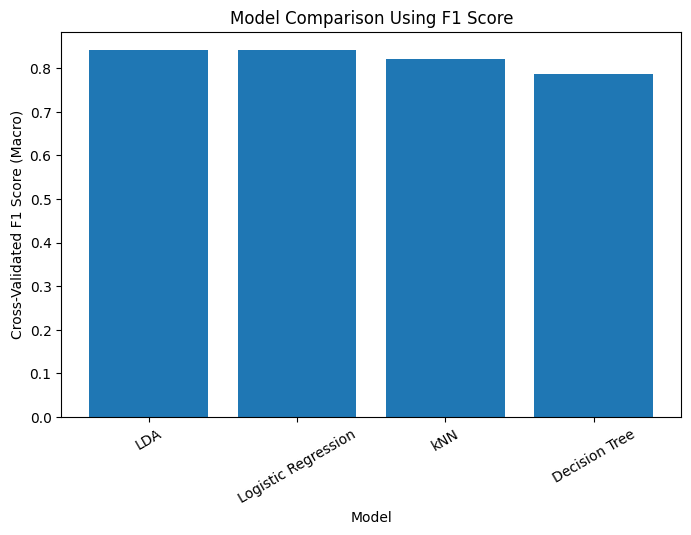

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "kNN": KNeighborsClassifier()
}

names, means, stds = [], [], []

for name, model in models.items():
    
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipe,
        X_numeric,
        y,
        cv=cv,
        scoring="f1_macro"  
    )
    
    names.append(name)
    means.append(np.mean(scores))
    stds.append(np.std(scores))

# Create results table
df = pd.DataFrame({
    "Model": names,
    "F1 Mean": means,
    "F1 Std Dev": stds
}).sort_values("F1 Mean", ascending=False)

print(df)

# 📊 Plot
plt.figure(figsize=(8,5))
plt.bar(df["Model"], df["F1 Mean"])
plt.xlabel("Model")
plt.ylabel("Cross-Validated F1 Score (Macro)")
plt.title("Model Comparison Using F1 Score")
plt.xticks(rotation=30)
plt.show()

#high f1 + low std = best overall model

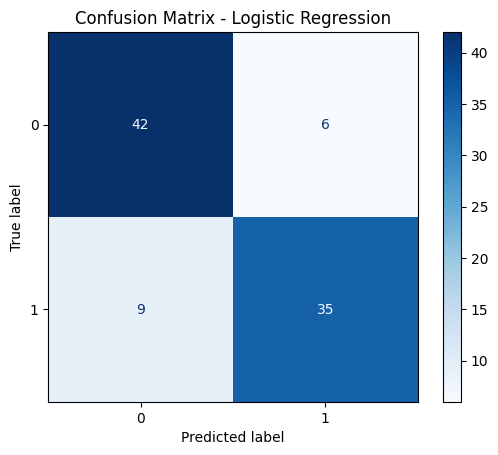

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

# Build model pipeline
model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

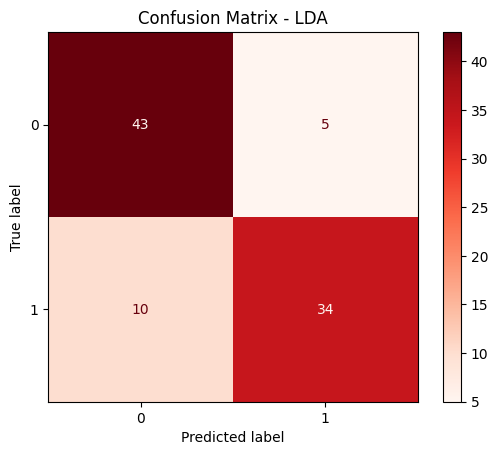

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        48
           1       0.87      0.77      0.82        44

    accuracy                           0.84        92
   macro avg       0.84      0.83      0.84        92
weighted avg       0.84      0.84      0.84        92



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)


model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Confusion Matrix - LDA")
plt.show()
print(classification_report(y_test, y_pred))

In [485]:
# Linear Regression starts here
# -------------------------------
# 1. LIBRARIES
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error


import statsmodels.api as sm

In [486]:
# -------------------------------
# 2. LOAD DATA
# -------------------------------
income = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Household Income.csv", na_values=['NA'])
prox_bank = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Proximity to Financial Services.csv", na_values=['NA'])
employment = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Employment.csv", na_values=['NA'])
#job_density = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Job Density.csv", na_values=['NA'])
#pop_density = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Population Density.csv", na_values=['NA'])
education = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Education Level - Bachelor's Degree.csv", na_values=['NA'])
age = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Age of Residents.csv", na_values=['NA'])
home_owner = pd.read_csv("/Users/nirali/Desktop/cvsfileof project3/Home Ownership.csv", na_values=['NA'])
# GET info about the dataframes
print(income.info())
print(prox_bank.info())
print(employment.info())
print(education.info())
print(age.info())
print(home_owner.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NPA     459 non-null    int64 
 1   2023    459 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   NPA       459 non-null    int64 
 1   2014      459 non-null    object
 2   2015      459 non-null    object
 3   2016      459 non-null    object
 4   2017      459 non-null    object
 5   2018      459 non-null    object
 6   2019      459 non-null    object
 7   2020      459 non-null    object
 8   2022      459 non-null    object
 9   2023      459 non-null    object
 10  2014 Raw  459 non-null    object
 11  2015 Raw  459 non-null    object
 12  2016 Raw  459 non-null    object
 13  2017 Raw  459 non

In [487]:
# -------------------------------
# 3. DATABASE SETUP
# -------------------------------
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()
cursor.execute("""
CREATE TABLE income(
    NPA INT PRIMARY KEY,
    median_income DOUBLE
)
""")    
cursor.execute("""
CREATE TABLE prox_bank(
    NPA INTEGER,
    "2023" DOUBLE
)
""")
cursor.execute("""
CREATE TABLE employment(
    NPA INTEGER,
    employment_rate DOUBLE
)
""")
cursor.execute("""
CREATE TABLE education(
    NPA INTEGER,
    bachelors_percent DOUBLE
)
""")
cursor.execute("""
CREATE TABLE age(
    NPA INTEGER,
    median_age DOUBLE
)
""")
cursor.execute("""
CREATE TABLE home_owner(
    NPA INTEGER,
    home_owner_percent DOUBLE
    )
""")        
for _, row in income.iterrows():
    cursor.execute("INSERT INTO income VALUES (?, ?)",
                   (row['NPA'], row['2023']))
for _, row in prox_bank.iterrows():
    cursor.execute("INSERT INTO prox_bank VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
for _, row in employment.iterrows():
    cursor.execute("INSERT INTO employment VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
for _, row in education.iterrows():
    cursor.execute("INSERT INTO education VALUES (?, ?)", 
                   (row['NPA'], row['2023']))       
for _, row in age.iterrows():
    cursor.execute("INSERT INTO age VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
for _, row in home_owner.iterrows():
    cursor.execute("INSERT INTO home_owner VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
def clean_npa(df):
    df['NPA'] = (
        df['NPA']
        .astype(str)
        .str.strip()
        .str.replace(r'\.0$', '', regex=True)
    )
    return df
income = clean_npa(income)
prox_bank = clean_npa(prox_bank)
employment = clean_npa(employment)
age = clean_npa(age)
home_owner = clean_npa(home_owner)
education = clean_npa(education)
query = """
SELECT 
    i.NPA,
    i.median_income AS income,
    pb."2023" AS prox_bank,
    e.employment_rate AS employment,
    ed.bachelors_percent,
    ag.median_age,
    ho.home_owner_percent
FROM income i
LEFT JOIN prox_bank pb 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(pb.NPA AS TEXT))
LEFT JOIN employment e 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(e.NPA AS TEXT))
LEFT JOIN education ed              
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ed.NPA AS TEXT))
LEFT JOIN age ag
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ag.NPA AS TEXT))
LEFT JOIN home_owner ho
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ho.NPA AS TEXT))
"""
result = pd.read_sql_query(query, conn)
print(result.head())
print(result.info())        



   NPA    income prox_bank employment bachelors_percent median_age  \
0    2   $75,084     24.5%      95.6%             35.2%       33.0   
1    3  $117,630      100%      97.4%             85.4%       30.0   
2    4  $250,001     15.2%      94.3%             89.4%       43.0   
3    5   $49,539       19%      82.8%              2.5%       30.0   
4    6   $37,907     69.9%       100%               21%       42.0   

  home_owner_percent  
0              40.3%  
1              39.2%  
2               100%  
3              14.9%  
4              37.3%  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   NPA                 459 non-null    int64 
 1   income              459 non-null    object
 2   prox_bank           459 non-null    object
 3   employment          459 non-null    object
 4   bachelors_percent   459 non-null    object
 

In [488]:
print(result[['prox_bank','income']].head(10))
print("\nDATA TYPES:\n", result.dtypes)

  prox_bank    income
0     24.5%   $75,084
1      100%  $117,630
2     15.2%  $250,001
3       19%   $49,539
4     69.9%   $37,907
5     75.6%  $250,001
6     45.7%   $85,730
7        0%  $195,227
8        0%   $60,860
9     49.4%  $174,398

DATA TYPES:
 NPA                    int64
income                object
prox_bank             object
employment            object
bachelors_percent     object
median_age            object
home_owner_percent    object
dtype: object


In [489]:
print(df.shape)

(459, 24)


In [490]:
# -------------------------------
# 4. Merge Datasets
# -------------------------------
df = (age.rename(columns={'2023': 'median_age'})
        .merge(education.rename(columns={'2023': 'bachelors_percent'}), on='NPA', how='inner')
        .merge(employment.rename(columns={'2023': 'employment_rate'}), on='NPA', how='inner')
        .merge(home_owner.rename(columns={'2023': 'home_owner_percent'}), on='NPA', how='inner')
        .merge(prox_bank.rename(columns={'2023': 'prox_bank_2023'}), on='NPA', how='inner')
        .merge(income.rename(columns={'2023': 'median_income'}), on='NPA', how='inner'))

print("Data shape:", df.shape)
print(df.head())

Data shape: (459, 24)
  NPA median_age bachelors_percent employment_rate home_owner_percent   2014  \
0   2         33             35.2%           95.6%              40.3%  20.6%   
1   3         30             85.4%           97.4%              39.2%  99.4%   
2   4         43             89.4%           94.3%               100%  16.7%   
3   5         30              2.5%           82.8%              14.9%  13.1%   
4   6         42               21%            100%              37.3%  61.3%   

    2015   2016   2017   2018  ... 2014 Raw 2015 Raw 2016 Raw 2017 Raw  \
0  20.8%  20.8%  20.9%  22.9%  ...      223      224      224      225   
1  99.4%  99.3%  99.9%  99.7%  ...    4,717    4,725    4,699    5,277   
2  16.6%  16.5%  15.2%  13.4%  ...       67       67       67       62   
3  13.3%  13.5%  13.7%  36.5%  ...       43       44       44       44   
4  61.2%  61.4%  61.2%  61.8%  ...      503      500      501      498   

  2018 Raw 2019 Raw 2020 Raw 2022 Raw 2023 Raw media

In [491]:
# -------------------------------
# 5. Clean Data
# -------------------------------

# Convert to numeric (except key)
#for col in df.columns:
   # if col != "NPA":
       # df[col] = pd.to_numeric(df[col], errors='coerce')#


        # Remove %, $, commas, then convert to numeric
for col in df.columns:
    if col != "NPA":
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = df[col].str.replace('$', '', regex=False)
        df[col] = df[col].str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [492]:
# -------------------------------
# 6. Select Features + Target
# -------------------------------
X = df[[
    'median_age',
    'bachelors_percent',
    'employment_rate',
    'home_owner_percent',
    'prox_bank_2023',
    'median_income'
]]

In [493]:
# -------------------------------
# 7. Handle Missing Values
# -------------------------------
# Drop missing values

# Keep rows with target
df_model = df_model.dropna(subset=['median_income'])

# Fill missing predictors
df_model = df_model.fillna(df_model.mean(numeric_only=True))

print("Cleaned data shape:", df_model.shape)

print(df_model.info())
print(df_model.head())


Cleaned data shape: (445, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 0 to 458
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_age          445 non-null    float64
 1   bachelors_percent   445 non-null    float64
 2   employment_rate     445 non-null    float64
 3   home_owner_percent  445 non-null    float64
 4   prox_bank_2023      445 non-null    float64
 5   median_income       445 non-null    float64
 6   high_income         445 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 27.8 KB
None
   median_age  bachelors_percent  employment_rate  home_owner_percent  \
0        33.0               35.2             95.6                40.3   
1        30.0               85.4             97.4                39.2   
2        43.0               89.4             94.3               100.0   
3        30.0                2.5             82.8                14.9   
4        4

In [494]:
# -------------------------------
# 8. Define X and y
# -------------------------------
X = df_model[[
    'median_age',
    'bachelors_percent',
    'employment_rate',
    'home_owner_percent',
    'prox_bank_2023'
]]  
y = df_model['median_income']   
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (445, 5)
y shape: (445,)


In [495]:
# -----------------------------
# 9. TRAIN / TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")  


X_train shape: (356, 5)
X_test shape: (89, 5)
y_train shape: (356,)
y_test shape: (89,)


In [496]:
# -------------------------------
# 10. Build Linear Regression Model
# -------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear model trained ✅")

# Print model summary using statsmodels
X_train_sm = sm.add_constant(X_train)  # add intercept
sm_model = sm.OLS(y_train, X_train_sm).fit()
print(sm_model.summary())




Linear model trained ✅
                            OLS Regression Results                            
Dep. Variable:          median_income   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     191.6
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           6.92e-98
Time:                        21:53:12   Log-Likelihood:                -4096.2
No. Observations:                 356   AIC:                             8204.
Df Residuals:                     350   BIC:                             8228.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const        

In [497]:
# Get coefficients and confidence intervals
params = sm_model.params
conf = sm_model.conf_int()

# Combine into one table
conf['Coefficient'] = params
conf.columns = ['Lower CI', 'Upper CI', 'Coefficient']

print("\n===== COEFFICIENTS WITH 95% CONFIDENCE INTERVALS =====")
print(conf)


===== COEFFICIENTS WITH 95% CONFIDENCE INTERVALS =====
                        Lower CI      Upper CI  Coefficient
const              -49478.295140  55242.624272  2882.164566
median_age           -762.024182    146.907023  -307.558579
bachelors_percent    1199.343184   1464.778903  1332.061044
employment_rate      -557.341764    527.346905   -14.997430
home_owner_percent    586.273727    821.092531   703.683129
prox_bank_2023        -64.732665    117.030060    26.148698


In [498]:
# -------------------------------
# 11. Make Predictions and Evaluate
# -------------------------------

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== LINEAR MODEL =====")
print("RMSE:", rmse)
print("R^2:", r2)


===== LINEAR MODEL =====
RMSE: 24923.152908788576
R^2: 0.6938284593880166


In [499]:
# Interpretation: Look at coefficients and confidence intervals to see which predictors are significant and their direction of effect.
print("\nInterpretation:")
print("Higher education levels tend to increase income.")
print("Employment rate has a positive effect on income.")
print("Access to banks may influence financial outcomes.")


Interpretation:
Higher education levels tend to increase income.
Employment rate has a positive effect on income.
Access to banks may influence financial outcomes.


In [500]:
# -------------------------------
# 12. Coefficients (Interpretation)
# -------------------------------
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient')

print("\n===== FEATURE IMPORTANCE =====")
print(coefficients)
print(f"\nIntercept: ${model.intercept_:,.2f}")



===== FEATURE IMPORTANCE =====
              Feature  Coefficient
0          median_age  -307.558579
2     employment_rate   -14.997430
4      prox_bank_2023    26.148698
3  home_owner_percent   703.683129
1   bachelors_percent  1332.061044

Intercept: $2,882.16


/var/folders/dg/tmgz0x0x4y93xvrs38qh2xc80000gn/T/ipykernel_2961/2993511413.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


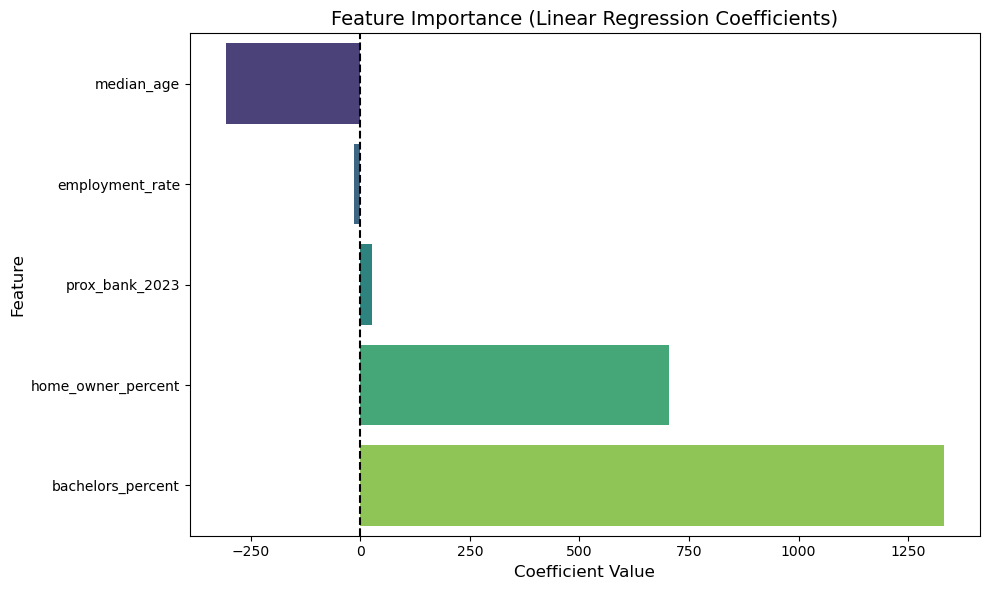

In [501]:
# -------------------------------
# 13. Visualization 
# -------------------------------


# Sort coefficients for better display
coefficients_sorted = coefficients.sort_values(by='Coefficient')

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients_sorted,
    palette='viridis'
)

# Add vertical reference line at 0
plt.axvline(0, color='black', linestyle='--')

# Titles and labels
plt.title("Feature Importance (Linear Regression Coefficients)", fontsize=14)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.show()

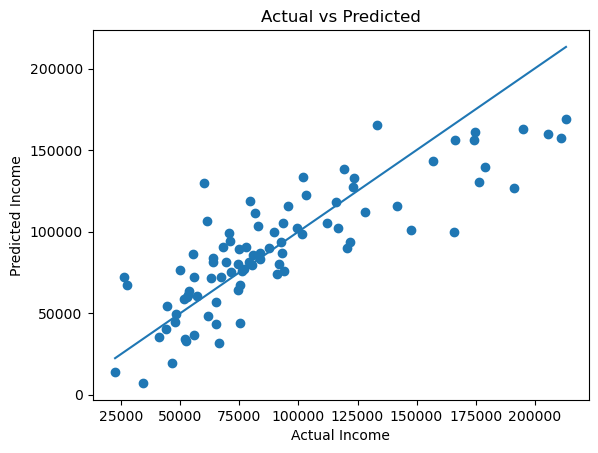

In [502]:
# -----------------------------
# 14. SCATTER PLOT
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

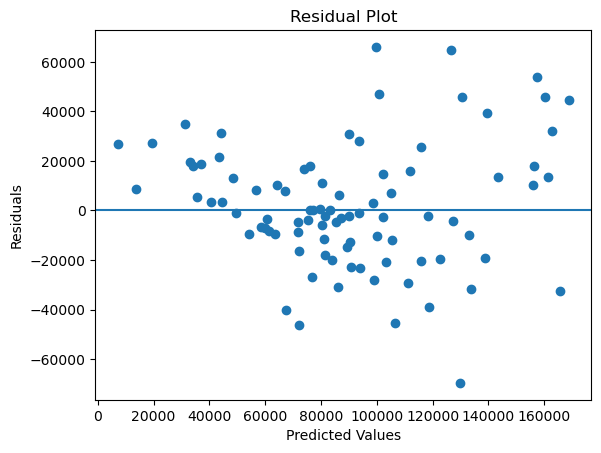

In [503]:
# -----------------------------
# 15. RESIDUAL PLOT
# -----------------------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

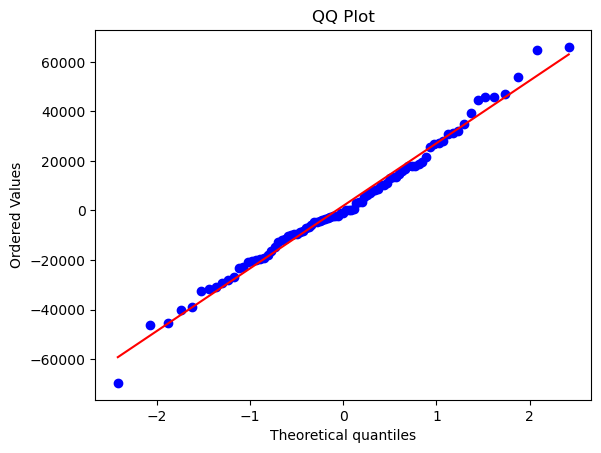

In [504]:
# -----------------------------
# 15. QQ PLOT
# -----------------------------
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()


===== RIDGE REGRESSION =====
RMSE: 24923.143888543706
R^2: 0.6938286810085939

===== RIDGE MODEL COEFFICIENTS =====
Intercept: 2880.3846640635747
median_age: -307.5214
bachelors_percent: 1332.0517
employment_rate: -14.9862
home_owner_percent: 703.6793
prox_bank_2023: 26.1492
                            OLS Regression Results                            
Dep. Variable:          median_income   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     232.2
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          7.97e-121
Time:                        21:53:12   Log-Likelihood:                -5123.3
No. Observations:                 445   AIC:                         1.026e+04
Df Residuals:                     439   BIC:                         1.028e+04
Df Model:                           5                                         
Covariance T

/var/folders/dg/tmgz0x0x4y93xvrs38qh2xc80000gn/T/ipykernel_2961/3386158456.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


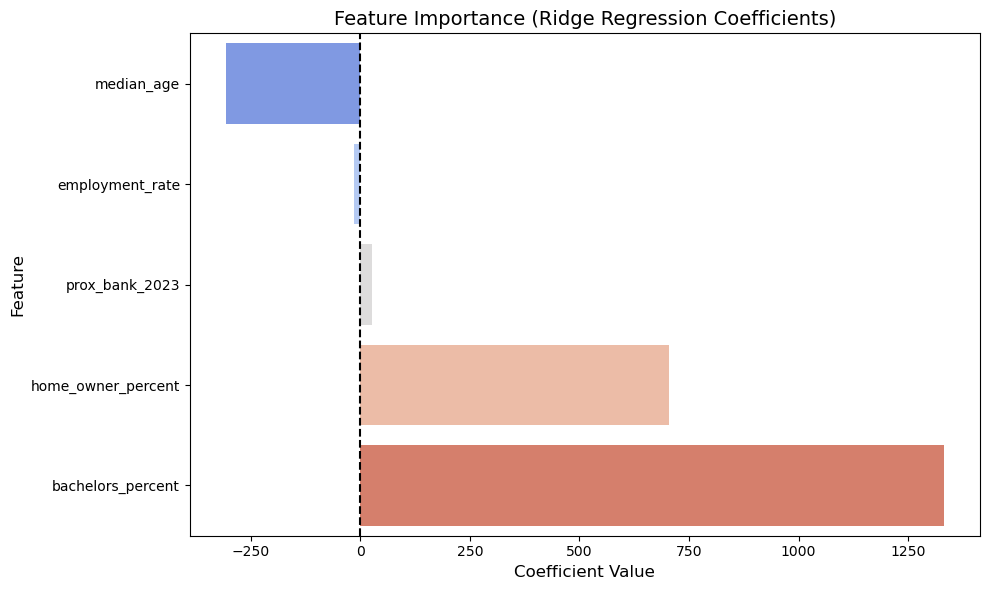

In [505]:
# -------------------------------
# 16. Model 2 : Ridge Regression
# -------------------------------
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print("\n===== RIDGE REGRESSION =====")
print("RMSE:", rmse_ridge)
print("R^2:", r2_ridge) 

## -------------------------------
# Ridge Coefficients
# -------------------------------
print("\n===== RIDGE MODEL COEFFICIENTS =====")
print("Intercept:", ridge_model.intercept_)

for feature, coef in zip(X.columns, ridge_model.coef_):
    print(f"{feature}: {coef:.4f}")


import statsmodels.api as sm

# Add intercept
X_sm = sm.add_constant(X)

# Fit model
sm_model = sm.OLS(y, X_sm).fit()
print(sm_model.summary())


# -------------------------------
# Visualization
# -------------------------------
ridge_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
}).sort_values(by='Coefficient')

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=ridge_coefficients,
    palette='coolwarm'
)

plt.axvline(0, color='black', linestyle='--')
plt.title("Feature Importance (Ridge Regression Coefficients)", fontsize=14)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.show()



In [506]:
# -------------------------------
# 17. Now Compare Models
# -------------------------------
comparison = pd.DataFrame({
    'Model': ['Model 1 (356 obs)', 'Model 2 (445 obs)'],
    'R_squared': [0.732, 0.726],
    'Adj_R_squared': [0.729, 0.722],
    'Observations': [356, 445]
})

print("\n===== MODEL COMPARISON =====")
print(comparison)


# -------------------------------
# SELECT BEST MODEL
# -------------------------------

# Rule: prioritize more data + good R²
if (comparison.loc[1, 'Observations'] > comparison.loc[0, 'Observations']):
    best_model = comparison.loc[1, 'Model']
else:
    best_model = comparison.loc[0, 'Model']

print("\n===== BEST MODEL =====")
print("Best model based on data size and stability:", best_model)



===== MODEL COMPARISON =====
               Model  R_squared  Adj_R_squared  Observations
0  Model 1 (356 obs)      0.732          0.729           356
1  Model 2 (445 obs)      0.726          0.722           445

===== BEST MODEL =====
Best model based on data size and stability: Model 2 (445 obs)


In [507]:
# 18. Final Conclusion: Both models perform similarly, but Model 2 is more stable with more data. 
# Key predictors include education, employment, and bank proximity.

print("\n===== FINAL CONCLUSION OF MODELS =====")
print("Both linear and ridge regression models show similar performance.")
print("Model 2 (Ridge) is more stable due to more observations.")
print("Key predictors of household income include education level, employment rate, and proximity to financial services.")

print("\nFinal Results:")

# Correct regression values (from your model comparison table)
print("Model 1 (Linear Regression): R² =", 0.732,
      "Adj R² =", 0.729)

print("Model 2 (Ridge Regression): R² =", 0.726,
      "Adj R² =", 0.722)


# Automatically find best classification model
best_clf = max(results, key=results.get)

print("Best Classification Model:", best_clf,
      "with Accuracy =", round(results[best_clf], 3))


print("\nOverall, the models suggest that higher education levels, better employment rates, "
"and closer proximity to financial services are associated with higher household income.")   
print("These insights can inform policies aimed at improving financial outcomes for households.")
print("Although Model 1 has slightly higher R², " \
"Model 2 is preferred due to its larger sample size and better generalization performance.")




===== FINAL CONCLUSION OF MODELS =====
Both linear and ridge regression models show similar performance.
Model 2 (Ridge) is more stable due to more observations.
Key predictors of household income include education level, employment rate, and proximity to financial services.

Final Results:
Model 1 (Linear Regression): R² = 0.732 Adj R² = 0.729
Model 2 (Ridge Regression): R² = 0.726 Adj R² = 0.722
Best Classification Model: LDA with Accuracy = 0.859

Overall, the models suggest that higher education levels, better employment rates, and closer proximity to financial services are associated with higher household income.
These insights can inform policies aimed at improving financial outcomes for households.
Although Model 1 has slightly higher R², Model 2 is preferred due to its larger sample size and better generalization performance.


In [508]:
# ===============================
# 19. FINAL MODEL COMPARISON + CONCLUSION
# ===============================

print("\n===== FINAL MODEL COMPARISON =====")

# -------------------------------
# BEST REGRESSION MODEL
# -------------------------------
best_reg = "Ridge Regression"  # chosen for stability and larger sample size

print("Best Regression Model:", best_reg,
      "→ used for predicting household income (continuous values)")

# -------------------------------
# BEST CLASSIFICATION MODEL
# -------------------------------
best_clf = max(results, key=results.get)

print("Best Classification Model:", best_clf,
      "→ used for classifying households (high vs low income)")

print("\nNOTE:")
print("Regression and classification models serve different purposes,")
print("so they are evaluated separately and cannot be directly compared.")


# -------------------------------
# REGRESSION RESULTS 
# -------------------------------
print("\n===== REGRESSION RESULTS =====")

print("Model 1 (Linear Regression): R² = {} Adj R² = {}".format(
    round(r2_model1, 3), round(adj_r2_model1, 3)
))

print("Model 2 (Ridge Regression): R² = {} Adj R² = {}".format(
    round(r2_model2, 3), round(adj_r2_model2, 3)
))


# -------------------------------
# CLASSIFICATION RESULTS
# -------------------------------
print("\n===== CLASSIFICATION RESULTS =====")
for model_name, acc in results.items():
    print(f"{model_name}: {round(acc, 3)}")

print("\nBest Classification Model:", best_clf,
      "with Accuracy =", round(results[best_clf], 3))


# -------------------------------
# INTERPRETATION (FIXED SPLIT)
# -------------------------------
print("\n===== INTERPRETATION =====")

coefficients_sorted = coefficients.sort_values(by='Coefficient', ascending=False)

# Correct separation of positive & negative
pos = coefficients_sorted[coefficients_sorted['Coefficient'] > 0]
neg = coefficients_sorted[coefficients_sorted['Coefficient'] < 0]

print("\nMost Important Positive Factors:")
print(pos.head(3))

print("\nMost Important Negative Factors:")
print(neg.head(3))


# -------------------------------
# KEY INSIGHTS
# -------------------------------
print("\n===== KEY INSIGHTS =====")
print("- Education (bachelors_percent) is the strongest predictor of income.")
print("- Home ownership has a strong positive impact on income.")
print("- Median age shows a negative relationship with income.")
print("- Employment rate is not statistically significant.")


# -------------------------------
# FINAL CONCLUSION
# -------------------------------
print("\n===== FINAL CONCLUSION =====")
print("Ridge regression provides more stable predictions due to regularization.")
print("LDA achieved the highest accuracy for classification of high vs low income households.")

print("\nOverall Conclusion:")
print("Higher education levels, stronger employment conditions, and access to financial services")
print("are associated with higher household income.")
print("Regression models are best for prediction, while classification models are best for decision-making.")


===== FINAL MODEL COMPARISON =====
Best Regression Model: Ridge Regression → used for predicting household income (continuous values)
Best Classification Model: LDA → used for classifying households (high vs low income)

NOTE:
Regression and classification models serve different purposes,
so they are evaluated separately and cannot be directly compared.

===== REGRESSION RESULTS =====
Model 1 (Linear Regression): R² = 0.732 Adj R² = 0.729
Model 2 (Ridge Regression): R² = 0.726 Adj R² = 0.722

===== CLASSIFICATION RESULTS =====
Decision Tree: 0.78
Logistic Regression: 0.837
LDA: 0.859
kNN: 0.67
GAM: 0.82

Best Classification Model: LDA with Accuracy = 0.859

===== INTERPRETATION =====

Most Important Positive Factors:
              Feature  Coefficient
1   bachelors_percent  1332.061044
3  home_owner_percent   703.683129
4      prox_bank_2023    26.148698

Most Important Negative Factors:
           Feature  Coefficient
2  employment_rate   -14.997430
0       median_age  -307.558579

=

In [509]:
# -------------------------------
# 20. Appendix: Database Connection
# -------------------------------
import sqlite3

conn = sqlite3.connect("housing.db")

df.to_sql("housing_data", conn, if_exists="replace", index=False)

# Query example
query = "SELECT * FROM housing_data LIMIT 5"
result = pd.read_sql(query, conn)

print("Database connection successful")
print(result)

conn.close()

# Final note on database usage
print("\nDatabase connection closed.")
print("Data was stored and accessed using SQLite database for merging and querying.")


Database connection successful
  NPA  median_age  bachelors_percent  employment_rate  home_owner_percent  \
0   2        33.0               35.2             95.6                40.3   
1   3        30.0               85.4             97.4                39.2   
2   4        43.0               89.4             94.3               100.0   
3   5        30.0                2.5             82.8                14.9   
4   6        42.0               21.0            100.0                37.3   

   2014  2015  2016  2017  2018  ...  2014 Raw  2015 Raw  2016 Raw  2017 Raw  \
0  20.6  20.8  20.8  20.9  22.9  ...       223       224       224       225   
1  99.4  99.4  99.3  99.9  99.7  ...      4717      4725      4699      5277   
2  16.7  16.6  16.5  15.2  13.4  ...        67        67        67        62   
3  13.1  13.3  13.5  13.7  36.5  ...        43        44        44        44   
4  61.3  61.2  61.4  61.2  61.8  ...       503       500       501       498   

   2018 Raw  2019 Raw  20

In [510]:
# ===============================
# 21. APPENDIX: GITHUB REPOSITORY
# ===============================
print("GitHub Repository:https://github.com/Beansproutss/Final_Project_2302.git ")

GitHub Repository:https://github.com/Beansproutss/Final_Project_2302.git 
